# Exercise 06

## Changes to the Evacuation Model

To enable exercises about learning and prediction, the evacuation model has been modified:

* adding statistics about the number of agents escaped through each of the exits
* Refactoring the `turn()` method (extracting exploration of field of vision)
* if an agent is blocked, its `nervousness` is increased by `NERVOUSNESS_INCREASE_BLOCKED` (default: 0.2)
* with low probability (`SPEED_RECOVERY_PROBABILTY = 0.15`), agents with `speed==0` increase their speed again (otherwise they likely get stuck)
* introduced `switches` for switching on/off various features (eg. cleverturn, predictcrowd)
* Introduction of agent memory to store agents' cooperativeness and the number of steps it took the agent to escape. This allows the learning of favorable values of cooperativeness accross model runs
* Introduction of learning of `cooperativeness`
  * 

## Evaluation Code


In [1]:
from mesa.batchrunner import batch_run
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import sys
sys.path.insert(0,'../../abmodel')

from fire_evacuation.model import FireEvacuation
from fire_evacuation.agent import Human


unikcolors = [np.array((80,149,200))/255, np.array((74,172,150))/255,
                                                  np.array((234,195,114))/255, np.array((199,16,92))/255]
uniks = LinearSegmentedColormap.from_list( 'unik', unikcolors)

def run_model(model_a, model_b, maxsteps = 100):
    fig = plt.figure(figsize=(12, 12))
    model_a.run(maxsteps)
    model_b.run(maxsteps)
    
    ax = fig.add_subplot(2, 1, 2)
    ax.set_xlabel("Steps")
    ax.set_ylabel("Number of escaped through the exit")
    da = model_a.datacollector.get_model_vars_dataframe()[['EscapedWest', 'EscapedSouth','EscapedEast', 'EscapedNorth']]
    db = model_b.datacollector.get_model_vars_dataframe()[['EscapedWest', 'EscapedSouth','EscapedEast', 'EscapedNorth']]
    db.columns = ['EscapedWest_B', 'EscapedSouth_B','EscapedEast_B', 'EscapedNorth_B']
    da.plot(ax=ax, colormap=uniks, ls="solid")
    db.plot(ax=ax, colormap=uniks, ls="dashed")

# Task 02 (Prediction in the evacuation model)

## Subtask 02

**Points: 15**

Currently, the time it takes to escape through a particular exit in the evacuation model (method `attempt_exit_plan()` in lines 378ff in `agent.py`) is predicted solely based on the distance from the current position to the exit door. How would you improve the prediction of time it takes to reach the exit? Try to sketch the required implementation in detail (500 words). Provide pseudo code to illustrate your idea (learn how to write code in Markdown via *Help* > *Markdown reference*).

**Describe your ideas here**

## Subtask 03

**Points: 20**

The `turn()` method (lines 333ff in `agent.py`) considers crowds such that the agent turns away from crowds. It therefore predicts the time it takes to escape from the number of agents in its field of vision (the agent does not consider that agents it perceives may head for different exits). Check whether this prediction helps by using the following code snippets!

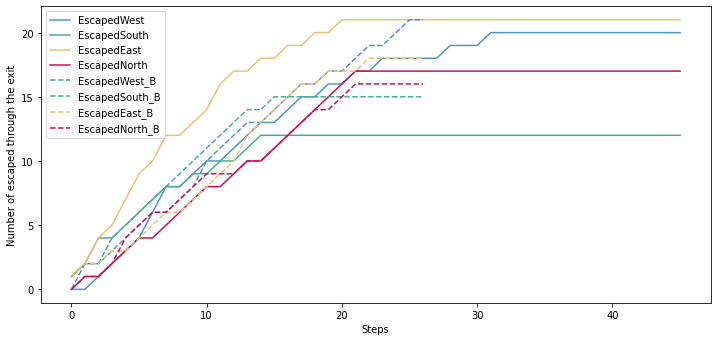

In [10]:
from IPython.utils import io
with io.capture_output() as captured:
    evacuation_a = FireEvacuation(floor_size = 14,
            human_count = 70,
            alarm_believers_prop = 1.0,
            max_speed = 2,
            cooperation_mean = 0.3,
            nervousness_mean = 0.5,
            predictcrowd = True,
            seed = 3)
    evacuation_b = FireEvacuation(floor_size = 14,
            human_count = 70,
            alarm_believers_prop = 1.0,
            max_speed = 2,
            cooperation_mean = 0.3,
            nervousness_mean = 0.5,
            predictcrowd = False,
            seed = 3)

    run_model(evacuation_a, evacuation_b, maxsteps = 100)

In [11]:
from IPython.utils import io
        
params = dict(
    floor_size=14,
    human_count=60,
    cooperation_mean = 0.3,
    nervousness_mean = 0.5,
    predictcrowd = {False, True},
    seed = range(0,30),
)

with io.capture_output() as captured:
    results = batch_run(
            FireEvacuation,
            parameters=params,
            data_collection_period = 1,
            iterations = 1,
            max_steps = 100,
        )

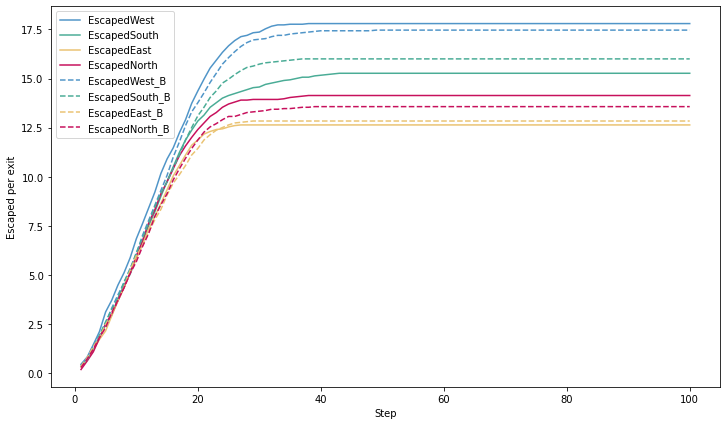

In [12]:
data = pd.DataFrame(results)[['predictcrowd', 'Step', 'seed','EscapedWest', 'EscapedSouth','EscapedEast', 'EscapedNorth']].round(decimals=1)

data = data.groupby(data['Step'].diff().lt(1).cumsum()) \
    .apply(lambda x: x.set_index('Step').reindex(range(1, 101)).transform(lambda x: x.fillna(x.max()))) \
    .reset_index(level=0, drop=True) \
    .reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_ylabel("Escaped per exit")
data[data['predictcrowd']==True].groupby(['Step']).agg(np.mean).drop(columns=['predictcrowd', 'seed']).plot(ax=ax, colormap=uniks, ls="solid")
db = data[data['predictcrowd']==False].groupby(['Step']).agg(np.mean).drop(columns=['predictcrowd', 'seed'])
db.columns = ['EscapedWest_B', 'EscapedSouth_B','EscapedEast_B', 'EscapedNorth_B']
plot = db.plot(ax=ax, colormap=uniks, ls="dashed")

In [13]:
data = pd.DataFrame(results)[['predictcrowd', 'Step', 'seed']].round(decimals=1)
db = data.groupby(['seed','predictcrowd']).agg(np.max).groupby(['predictcrowd']).agg(np.mean)
db

,Step
predictcrowd,
False,36.700000
True,33.533333


Are there differences depending on number of humans and level of initial nervousness? The following code is to investigate number of humans in the room. Analyse it (you may also change the levels), then copy the code and adapt it to investigate levels of initial nervousness.

In [ ]:
from IPython.utils import io
        
params = dict(
    floor_size=14,
    human_count={40,60,80},
    cooperation_mean = 0.3,
    nervousness_mean = 0.5,
    predictcrowd = {False, True},
    seed = range(0,20),
)

with io.capture_output() as captured:
    results = batch_run(
            FireEvacuation,
            parameters=params,
            data_collection_period = 1,
            iterations = 1,
            max_steps = 100,
        )
    
data = pd.DataFrame(results)[['predictcrowd', 'human_count', 'Step', 'seed']].round(decimals=1)
stepstoevacuation = data.groupby(['seed','predictcrowd', 'human_count']).agg(np.max).groupby(['predictcrowd', 'human_count']).agg(np.mean)
stepstoevacuation

**Describe your finding here (learn about Markdown syntax via Menu > Help > Markdown Reference)!**

## Subtask 04

**Points: 20**

Think about improving the prediction in the `turn()` method. Find at two options and compare them in terms of effort to perform the prediction both in terms of cognitive load and implementation, and potential benefit to the agent. Would it make sense to implement agents heterogeneously regarding their way to predict?

**Describe your findings here (300 words, possibly a table)**

# Task 02 (Exploring learning in the evacuation model)

## Subtask 01

**Points: 15**

When learning, agents seek to improve their behaviour according to a fitness function. In the evacuation model, the *fitness* relates to the time it takes for an agent to escape the room. In this exercise, we're going to have the agents learn optimal values of cooperativeness.

In the evacuation model, learning benefitial levels of cooperation was added. Therefore, agents memorise their cooperativeness and the time it takes to evacuate the entire room. At the beginning, cooperation is changed randomly. After the memory is filled, agents identify the best evacuation, choose the according cooperativeness value, and change it slightly to improve further:

Execute the following code:

In [1]:
from mesa.batchrunner import batch_run
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import sys
sys.path.insert(0,'../../abmodel')

from fire_evacuation.model import FireEvacuation
from fire_evacuation.agent import Human


unikcolors = [np.array((80,149,200))/255, np.array((74,172,150))/255,
                                                  np.array((234,195,114))/255, np.array((199,16,92))/255]
uniks = LinearSegmentedColormap.from_list( 'unik', unikcolors)

def run_model(model_a, model_b, maxsteps = 100):
    fig = plt.figure(figsize=(12, 12))
    model_a.run(maxsteps)
    model_b.run(maxsteps)
    
    ax = fig.add_subplot(2, 1, 2)
    ax.set_xlabel("Steps")
    ax.set_ylabel("Number of escaped through the exit")
    da = model_a.datacollector.get_model_vars_dataframe()[['EscapedWest', 'EscapedSouth','EscapedEast', 'EscapedNorth']]
    db = model_b.datacollector.get_model_vars_dataframe()[['EscapedWest', 'EscapedSouth','EscapedEast', 'EscapedNorth']]
    db.columns = ['EscapedWest_B', 'EscapedSouth_B','EscapedEast_B', 'EscapedNorth_B']
    da.plot(ax=ax, colormap=uniks, ls="solid")
    db.plot(ax=ax, colormap=uniks, ls="dashed")

In [2]:
from IPython.utils import io
with io.capture_output() as captured:
    evacuation = FireEvacuation(floor_size = 14,
            human_count = 70,
            alarm_believers_prop = 1.0,
            max_speed = 2,
            cooperation_mean = 0.3,
            nervousness_mean = 0.5,
            predictcrowd = True,
            seed = 3)
    
    # Run the model
    evacuation.run(100)
    
    # Store the agent memory
    memories = evacuation.get_agentmemories()

In [ ]:
# Rerun the model starting with state of agente' memory of last run
for _ in range(0,20):
    evacuation = FireEvacuation(floor_size = 14,
            human_count = 70,
            alarm_believers_prop = 1.0,
            max_speed = 2,
            cooperation_mean = 0.3,
            nervousness_mean = 0.5,
            predictcrowd = True,
            agentmemories = memories,
            seed = 3)
    evacuation.run(100)
    memories = evacuation.get_agentmemories()
    
    counter = 0
    steps2escape = 0
    cooperativeness = 0
    for agent in evacuation.schedule.agents:
        if isinstance(agent, Human):
            counter +=1
            steps2escape += agent.numsteps2escape
            cooperativeness += agent.cooperativeness
            
    print("Avg. steps to escape: " + str(steps2escape/counter) + " | cooperativeness: " + str(cooperativeness/counter) + 
          " | last step: " + str(evacuation.schedule.steps))

In [ ]:
# You may want to expore singel agent's memory. Note that only the last *memorysize* entries are considered.
memories = evacuation.get_agentmemories()
df = memories[memories['agent']==3]
df.sort_values('cooperativeness').set_index('cooperativeness').drop(columns=['step','agent']).plot()
df

As you may observe, learning does not work well as the number of steps to evacuate the room are not minimal at the end. What makes learning difficult in the evacuation model? Discuss two reasons (think of *determinism* and *coordination*).

**Place your answer here (max 300 words)**

## Subtask 02

**Points: 10**

What prediction is implicit in the way learning happens about the best level of cooperativeness?

**Write your answer here (<200 words)!**

## Subtask 03

**Points: 15**

Find arguments pro and contra the statement, that changing cooperativeness level in the evacuation model is learning!

**State your arguments here (<300 words)**